Using: cuda


100%|██████████| 20.9M/20.9M [00:00<00:00, 75.8MB/s]

Extracting files...


Using data from: /root/.cache/kagglehub/datasets/anandkumarsahu09/cattle-breeds-dataset/versions/1/Cattle Breeds
Classes: ['Ayrshire cattle', 'Brown Swiss cattle', 'Holstein Friesian cattle', 'Jersey cattle', 'Red Dane cattle']
Train=965  Val=119  Test=124
Epoch 01/50 | Train Acc=34.61% | Val Acc=41.18%
Saved new BEST model
Epoch 02/50 | Train Acc=36.27% | Val Acc=44.54%
Saved new BEST model
Epoch 03/50 | Train Acc=43.52% | Val Acc=48.74%
Saved new BEST model
Epoch 04/50 | Train Acc=47.46% | Val Acc=55.46%
Saved new BEST model
Epoch 05/50 | Train Acc=46.11% | Val Acc=59.66%
Saved new BEST model
Epoch 06/50 | Train Acc=52.44% | Val Acc=52.10%
Epoch 07/50 | Train Acc=53.68% | Val Acc=60.50%
Saved new BEST model
Epoch 08/50 | Train Acc=53.06% | Val Acc=60.50%
Epoch 09/50 | Train Acc=56.06% | Val Acc=63.03%
Saved new BEST model
Epoch 10/50 | Train Acc=56.58% | Val Acc=63.87%
Saved new BEST model
Epoch 11/50 | Train Acc=56.27% | Val Acc=63.87%
Epoch 12/50 | Train Acc=59.17% | Val Acc=61.34%

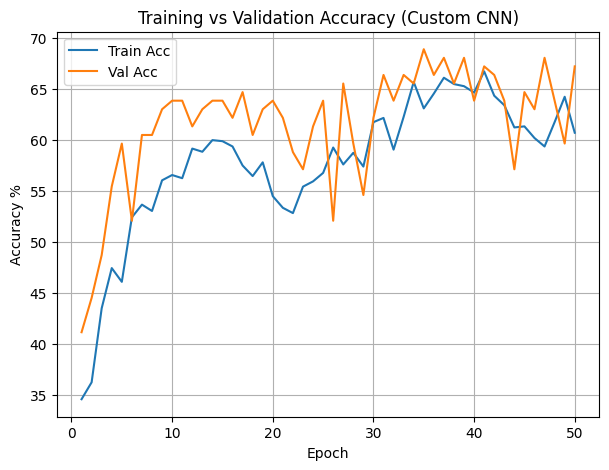

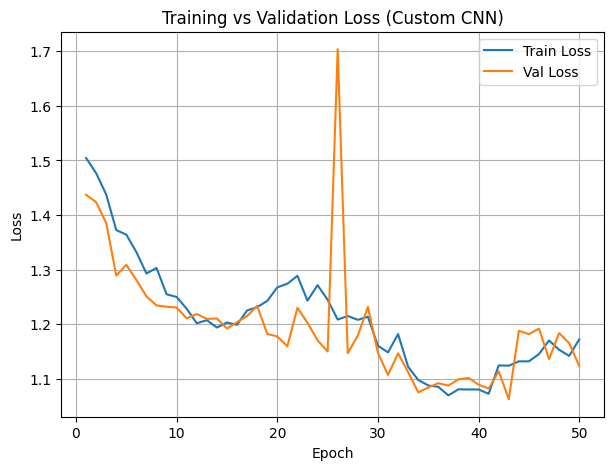

In [ ]:
# ============================================================
# CUSTOM CNN FOR CATTLE BREED CLASSIFICATION (OPTIMIZED)
# ============================================================

import os
import kagglehub
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report

# -------------------------------
# SEED & DEVICE
# -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# -------------------------------
# DATASET DOWNLOAD
# -------------------------------
path = kagglehub.dataset_download("anandkumarsahu09/cattle-breeds-dataset")
DATA_DIR = os.path.join(path, "Cattle Breeds")
print("Using data from:", DATA_DIR)

# -------------------------------
# TRANSFORMS
# -------------------------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------------------------------
# LOAD DATASET
# -------------------------------
base = datasets.ImageFolder(DATA_DIR, transform=test_transform)
class_names = base.classes
num_classes = len(class_names)
print("Classes:", class_names)

# -------------------------------
# STRATIFIED SPLIT
# -------------------------------
def stratified_split(dataset):
    rng = np.random.default_rng(SEED)
    groups = defaultdict(list)

    for i, (_, lb) in enumerate(dataset.samples):
        groups[lb].append(i)

    train, val, test = [], [], []

    for arr in groups.values():
        arr = np.array(arr)
        rng.shuffle(arr)
        n = len(arr)
        t = int(0.8*n)
        v = int(0.1*n)
        train += arr[:t].tolist()
        val += arr[t:t+v].tolist()
        test += arr[t+v:].tolist()

    return train, val, test

train_idx, val_idx, test_idx = stratified_split(base)

class SubsetWithTransform(Dataset):
    def __init__(self, base, idxs, tfm):
        self.base = base
        self.idxs = idxs
        self.tfm = tfm

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        path, label = self.base.samples[self.idxs[i]]
        img = self.base.loader(path)
        return self.tfm(img), label

train_ds = SubsetWithTransform(base, train_idx, train_transform)
val_ds   = SubsetWithTransform(base, val_idx, test_transform)
test_ds  = SubsetWithTransform(base, test_idx, test_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)

print(f"Train={len(train_ds)}  Val={len(val_ds)}  Test={len(test_ds)}")

# ============================================================
# CUSTOM CNN ARCHITECTURE (Optimized with Skip Connections)
# ============================================================
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU()
        )
        self.shortcut64 = nn.Conv2d(3, 64, 1)
        self.pool1 = nn.MaxPool2d(2)

        self.layer2 = nn.Sequential(
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU()
        )
        self.shortcut128 = nn.Conv2d(64,128,1)
        self.pool2 = nn.MaxPool2d(2)

        self.layer3 = nn.Sequential(
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU()
        )
        self.shortcut256 = nn.Conv2d(128,256,1)
        self.pool3 = nn.MaxPool2d(2)

        self.layer4 = nn.Sequential(
            nn.Conv2d(256,512,3,padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Dropout(0.4)
        )
        self.pool4 = nn.MaxPool2d(2)

        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        sc = self.shortcut64(x)
        x = self.layer1(x) + sc
        x = self.pool1(x)

        sc = self.shortcut128(x)
        x = self.layer2(x) + sc
        x = self.pool2(x)

        sc = self.shortcut256(x)
        x = self.layer3(x) + sc
        x = self.pool3(x)

        x = self.layer4(x)
        x = self.pool4(x)

        x = self.gap(x).flatten(1)
        return self.fc(x)

model = CustomCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12)

# ============================================================
# TRAINING
# ============================================================
train_acc_hist = []
val_acc_hist = []
train_loss_hist = []
val_loss_hist = []

best = 0
EPOCHS = 50

for ep in range(1, EPOCHS+1):
    model.train()
    correct = total = 0
    loss_sum = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = loss_sum / len(train_loader)
    scheduler.step()

    # Validation
    model.eval()
    v_correct = v_total = v_loss = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            v_loss += criterion(out, labels).item()
            v_correct += (out.argmax(1) == labels).sum().item()
            v_total += labels.size(0)

    val_acc = 100 * v_correct / v_total
    val_loss = v_loss / len(val_loader)

    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)
    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)

    print(f"Epoch {ep:02d}/{EPOCHS} | Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}%")

    if val_acc > best:
        best = val_acc
        torch.save(model.state_dict(), "best_customcnn.pth")
        print("Saved new BEST model")

print("\nBest Validation Accuracy:", best)

# ============================================================
# TEST EVALUATION
# ============================================================
model.load_state_dict(torch.load("best_customcnn.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\n=== TEST REPORT ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ============================================================
# GRAPHS
# ============================================================
epochs = range(1, len(train_acc_hist) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, train_acc_hist, label="Train Acc")
plt.plot(epochs, val_acc_hist, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.title("Training vs Validation Accuracy (Custom CNN)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, train_loss_hist, label="Train Loss")
plt.plot(epochs, val_loss_hist, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Custom CNN)")
plt.grid(True)
plt.legend()
plt.show()


Saving rd.jpeg to rd (1).jpeg
Image: rd (1).jpeg

Predicted Breed: Jersey cattle
Confidence: 0.893128514289856


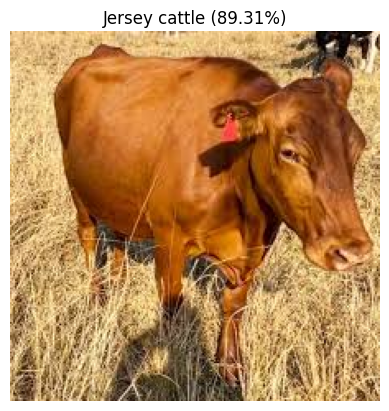

In [ ]:
# ============================
# IMAGE PREDICTION (UPLOAD FILE)
# ============================

from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt   # <-- ADD THIS

uploaded = files.upload()  # Choose an image

for filename in uploaded.keys():
    img_path = filename
    print("Image:", img_path)

    # Load the image
    img = Image.open(img_path).convert("RGB")

    # Apply same preprocess as test dataset
    tfm = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485,0.456,0.406],
            [0.229,0.224,0.225],
        ),
    ])

    x = tfm(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        out = model(x)
        prob = torch.softmax(out, dim=1)[0]
        pred_idx = prob.argmax().item()

    print("\nPredicted Breed:", class_names[pred_idx])
    print("Confidence:", float(prob[pred_idx]))

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_names[pred_idx]} ({prob[pred_idx]*100:.2f}%)")
    plt.show()


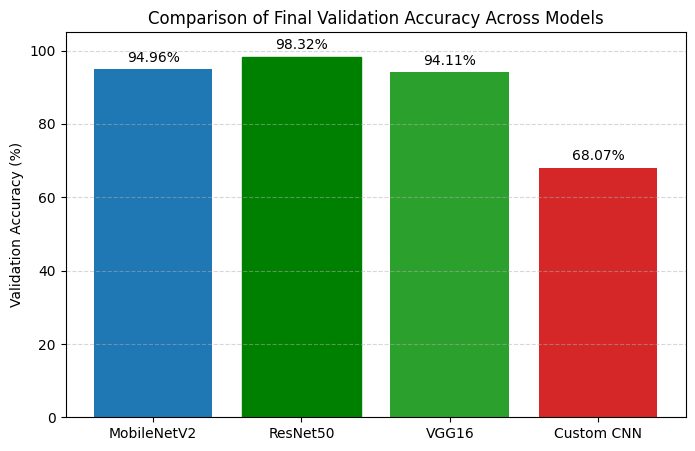

In [ ]:
import matplotlib.pyplot as plt

# Final Validation Accuracies
models = ["MobileNetV2", "ResNet50", "VGG16", "Custom CNN"]
val_acc = [94.96, 98.32, 94.11, 68.07]   # final model accuracies

plt.figure(figsize=(8,5))
bars = plt.bar(models, val_acc, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])

# Highlight best model (ResNet50)
best_idx = val_acc.index(max(val_acc))
bars[best_idx].set_color("green")

# Labels+++++++++++++++++++++++++++++++++++++++++++++++++++++++
.
plt.ylabel("Validation Accuracy (%)")
plt.title("Comparison of Final Validation Accuracy Across Models")
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add accuracy values on top of bars
for i, v in enumerate(val_acc):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontsize=10)

plt.savefig("comparison.png", dpi=300, bbox_inches="tight")
plt.show()
